In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import category_encoders as ce

In [2]:
df = pd.read_csv('../data/income_evaluation.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              32561 non-null  int64 
 1    workclass       32561 non-null  object
 2    fnlwgt          32561 non-null  int64 
 3    education       32561 non-null  object
 4    education-num   32561 non-null  int64 
 5    marital-status  32561 non-null  object
 6    occupation      32561 non-null  object
 7    relationship    32561 non-null  object
 8    race            32561 non-null  object
 9    sex             32561 non-null  object
 10   capital-gain    32561 non-null  int64 
 11   capital-loss    32561 non-null  int64 
 12   hours-per-week  32561 non-null  int64 
 13   native-country  32561 non-null  object
 14   income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df.isnull().sum()

age                0
 workclass         0
 fnlwgt            0
 education         0
 education-num     0
 marital-status    0
 occupation        0
 relationship      0
 race              0
 sex               0
 capital-gain      0
 capital-loss      0
 hours-per-week    0
 native-country    0
 income            0
dtype: int64

Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Target column: income


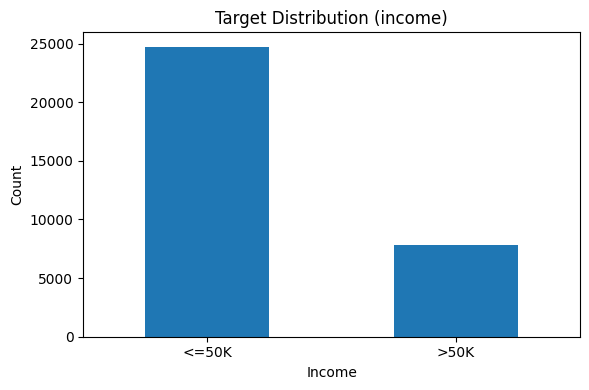

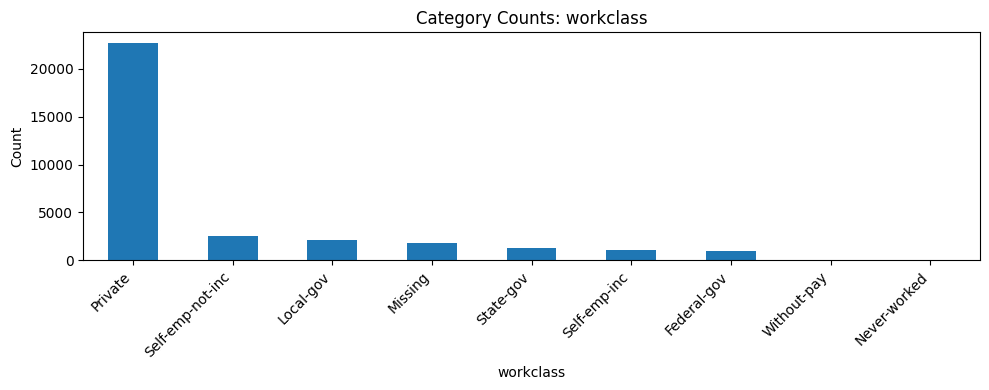

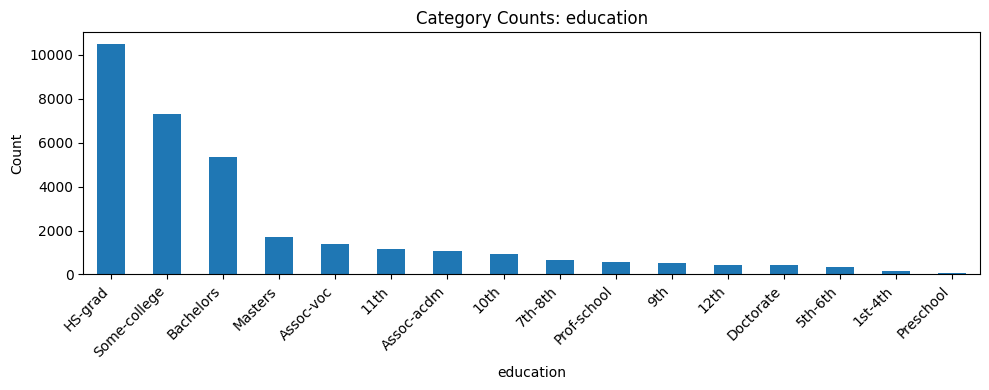

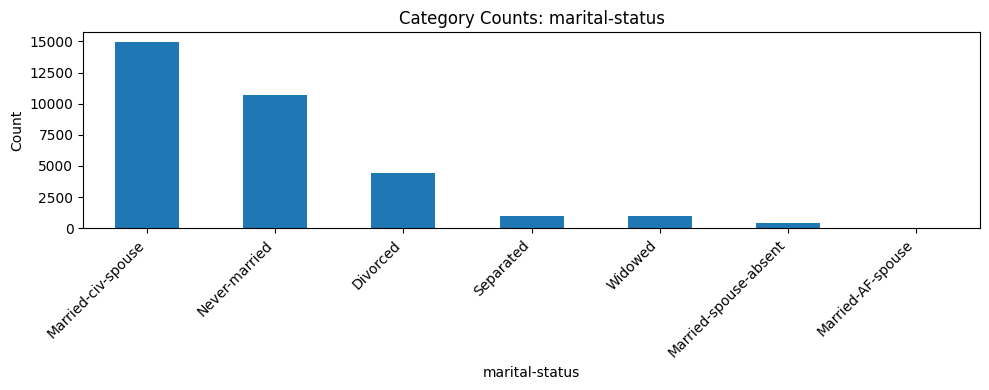

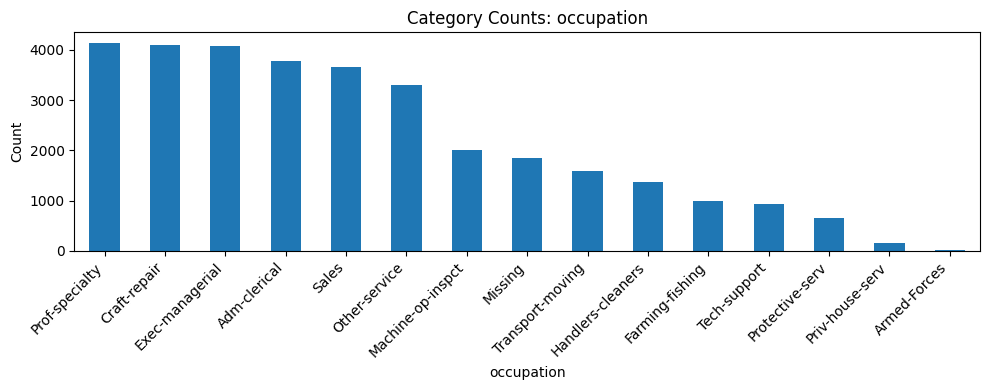

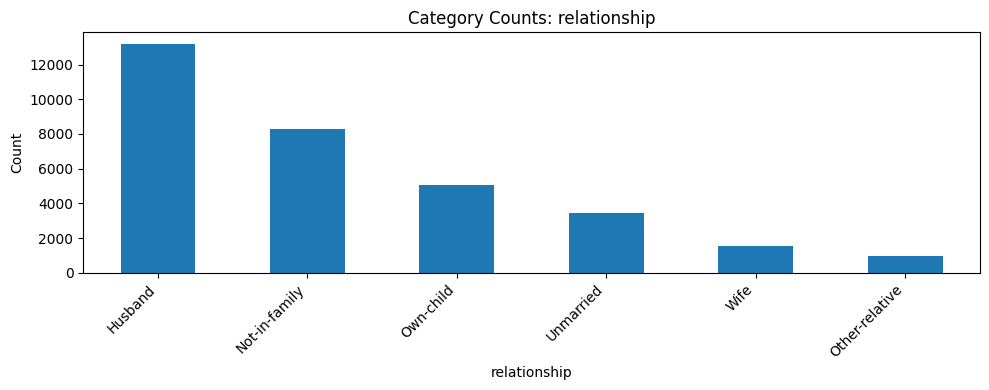

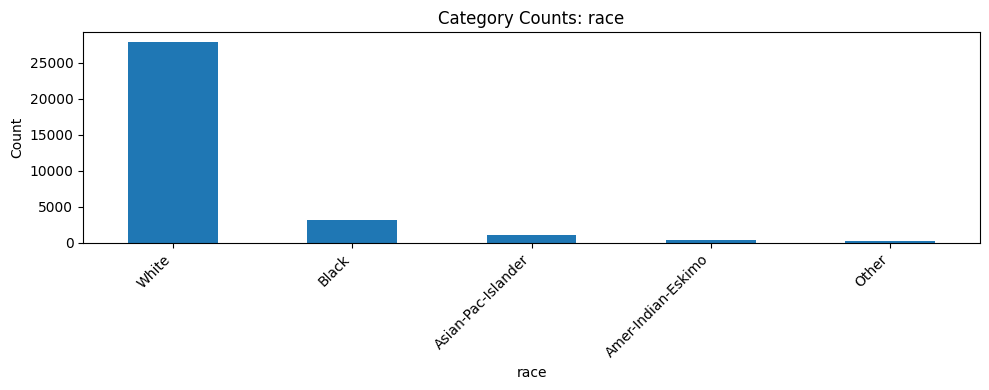

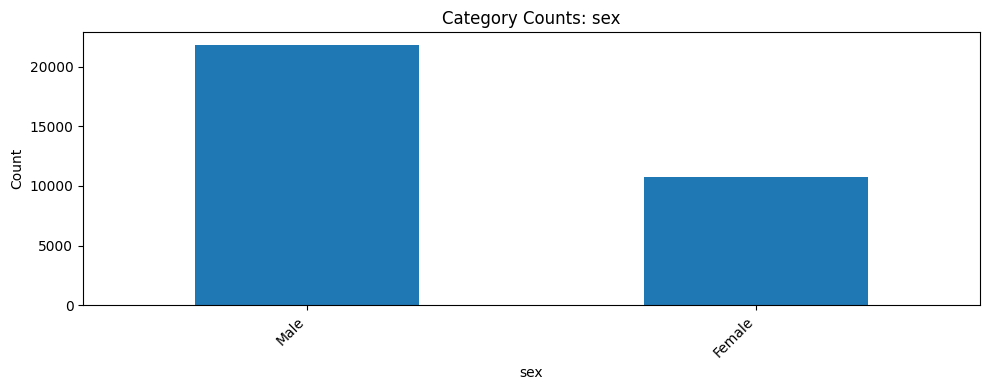

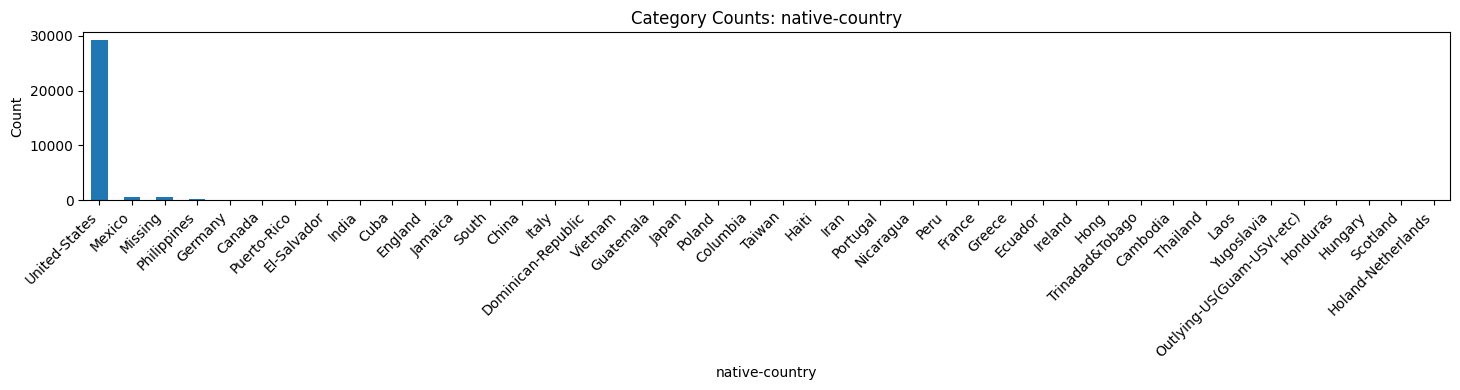

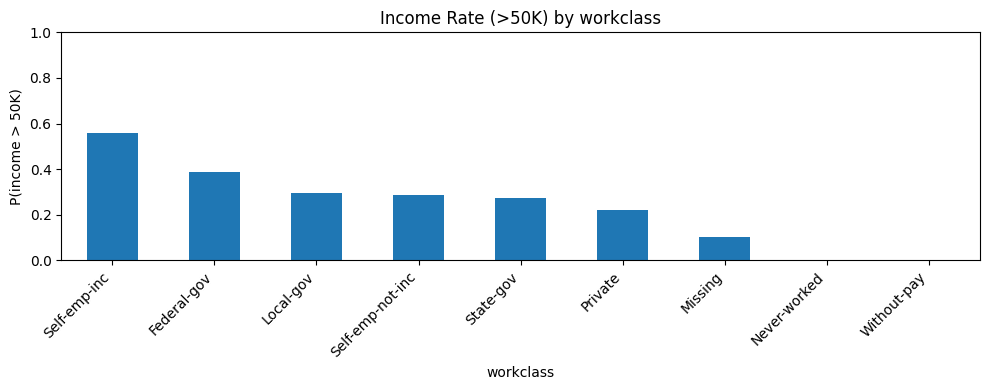

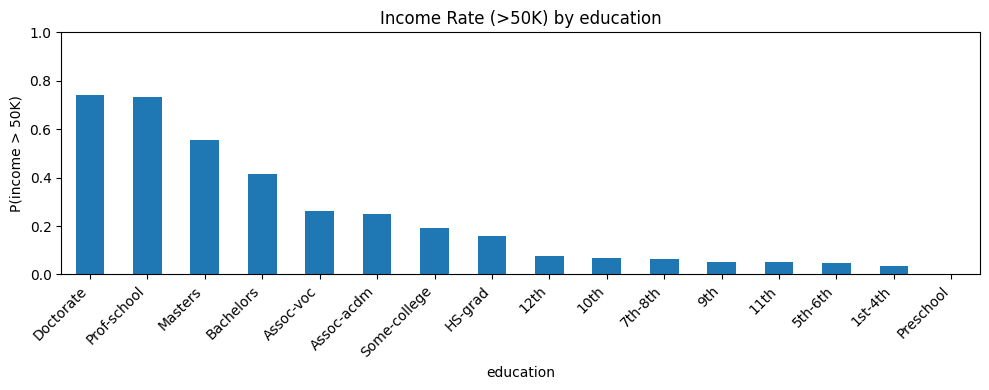

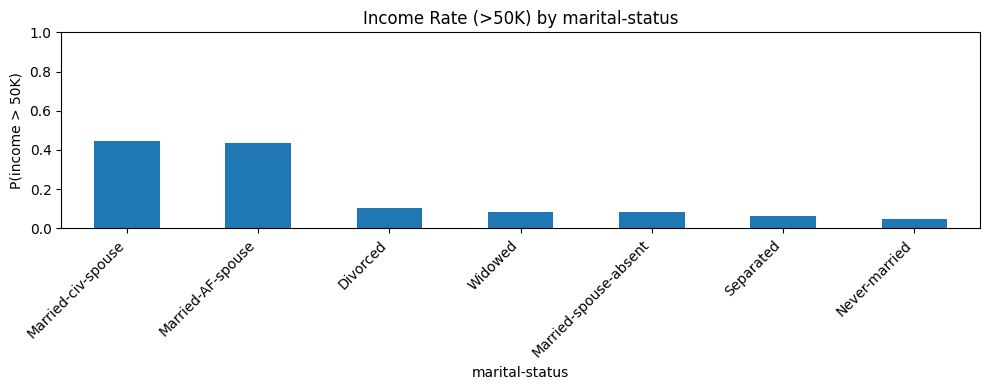

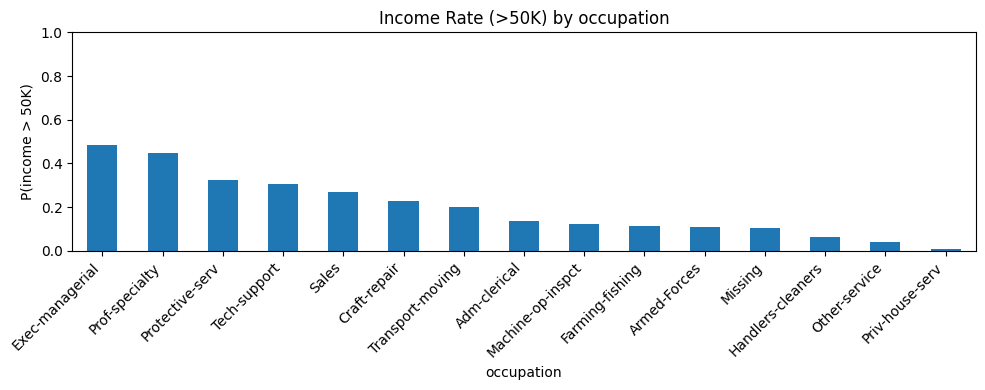

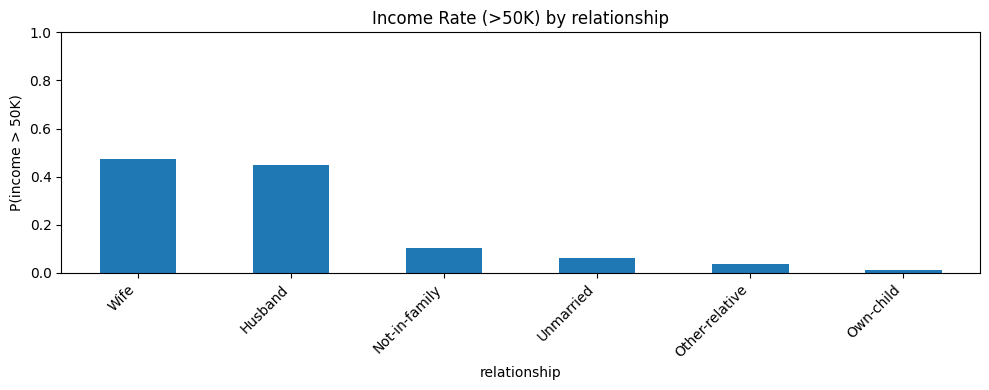

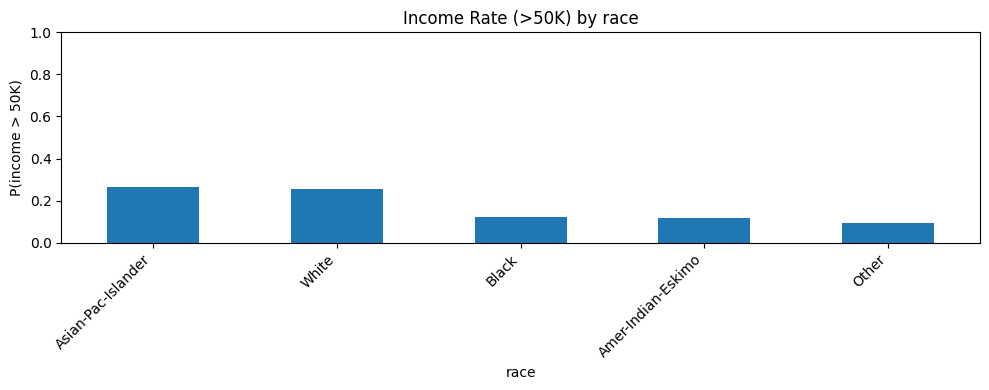

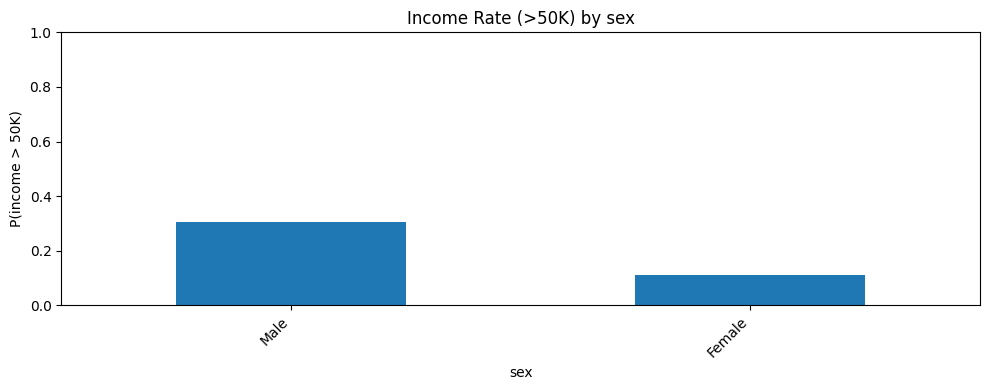

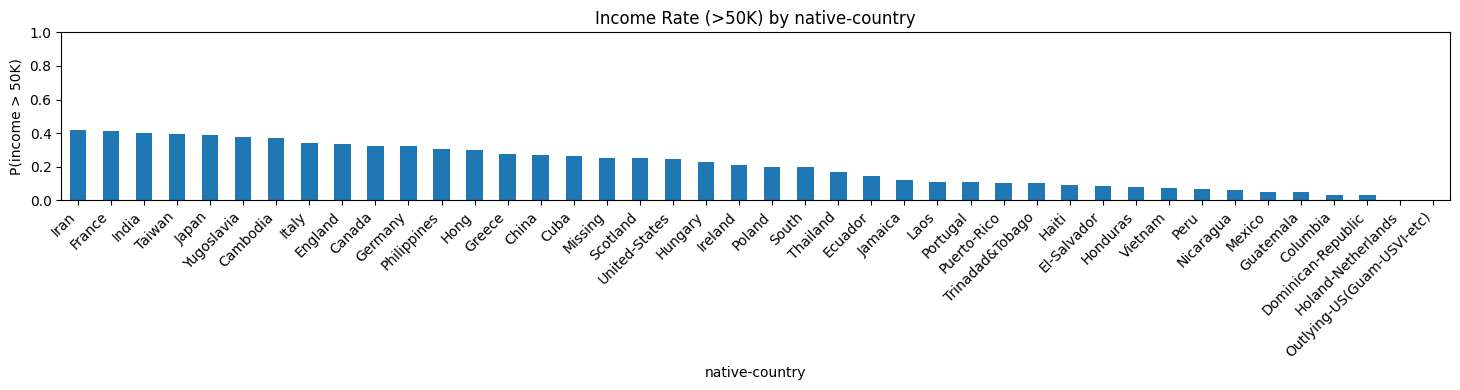

C:\Users\alice_t2i23g8\AppData\Local\Temp\ipykernel_23996\3617581131.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


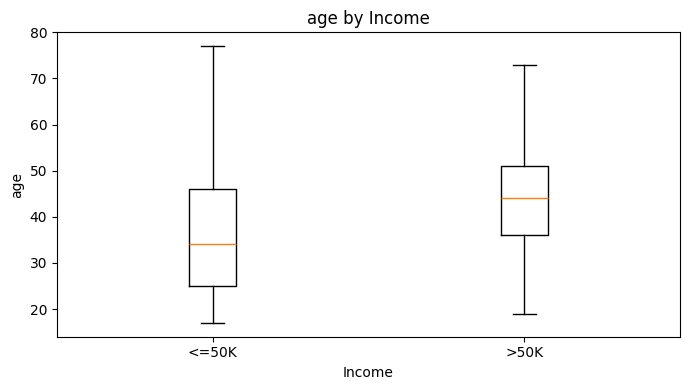

C:\Users\alice_t2i23g8\AppData\Local\Temp\ipykernel_23996\3617581131.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


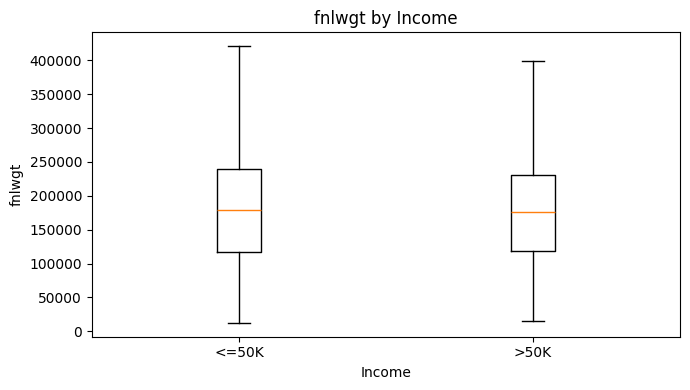

C:\Users\alice_t2i23g8\AppData\Local\Temp\ipykernel_23996\3617581131.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


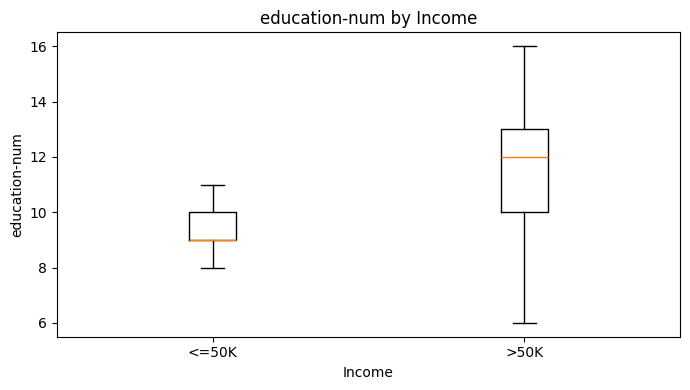

C:\Users\alice_t2i23g8\AppData\Local\Temp\ipykernel_23996\3617581131.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


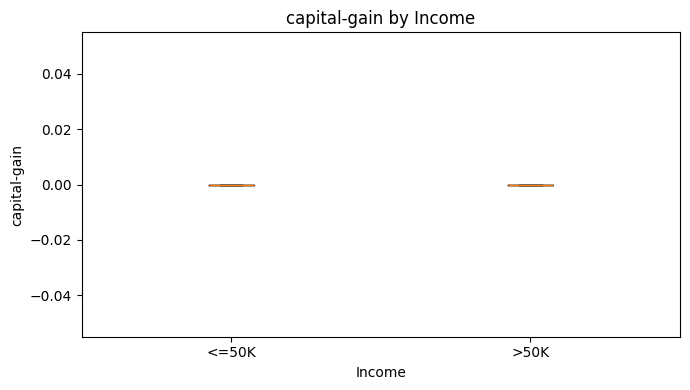

C:\Users\alice_t2i23g8\AppData\Local\Temp\ipykernel_23996\3617581131.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


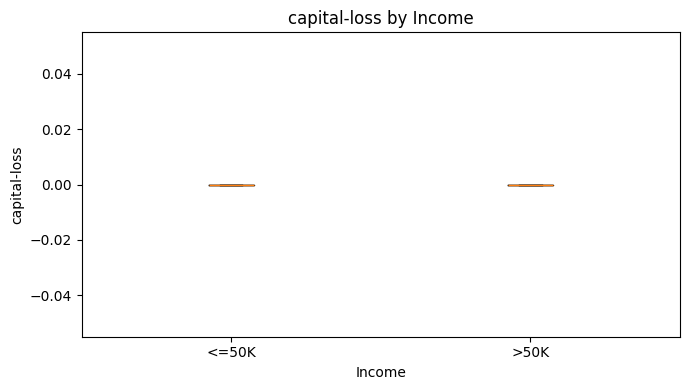

C:\Users\alice_t2i23g8\AppData\Local\Temp\ipykernel_23996\3617581131.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


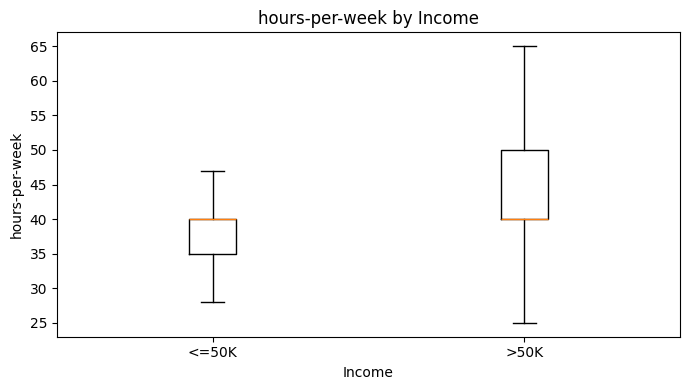

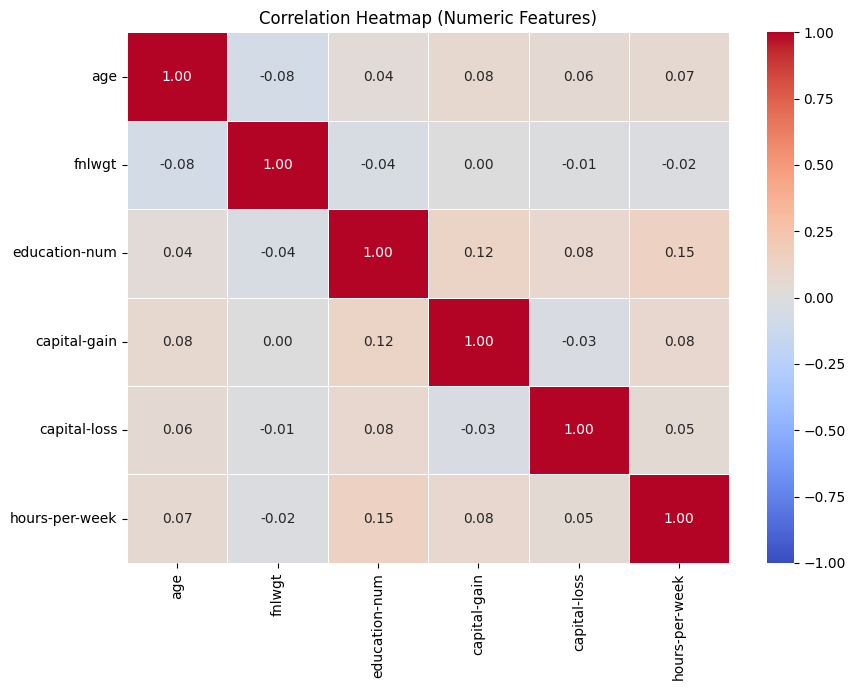

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 0) Cleanning and preprocessing
# -----------------------------

# Strip column names (fixes " income" problem)
df.columns = df.columns.str.strip()

target_col = "income"

# Strip whitespace in all object columns without breaking NaNs
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

# Replace ? with NaN
df = df.replace("?", np.nan)

# Convert NaNs in categorical columns into "Missing"
cat_cols = df.select_dtypes(include="object").columns.drop(target_col, errors="ignore")
for col in cat_cols:
    df[col] = df[col].fillna("Missing")

# Identify columns 
cat_cols = df.select_dtypes(include="object").columns.drop(target_col, errors="ignore") 
num_cols = df.select_dtypes(include=np.number).columns 
print("Categorical columns:", list(cat_cols)) 
print("Numeric columns:", list(num_cols)) 
print("Target column:", target_col)

# -----------------------------
# 1) Target distribution
# -----------------------------
plt.figure(figsize=(6, 4))
df[target_col].value_counts(dropna=False).plot(kind="bar")
plt.title("Target Distribution (income)")
plt.xlabel("Income")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# -----------------------------
# 2) Category counts for ALL categories (each categorical feature)
# -----------------------------
for col in cat_cols:
    counts = df[col].value_counts(dropna=False)

    plt.figure(figsize=(max(10, len(counts) * 0.35), 4))
    counts.plot(kind="bar")
    plt.title(f"Category Counts: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 3) Income rate by ALL categories (each categorical feature)
# -----------------------------
income_map = {
    "<=50K": 0, "<=50K.": 0,
    ">50K": 1, ">50K.": 1
}
df["_income_binary"] = df[target_col].map(income_map)

if df["_income_binary"].isna().any():
    raise ValueError(
        f"Income labels not recognized. Found: {df[target_col].unique()}"
    )

for col in cat_cols:
    rate = df.groupby(col, dropna=False)["_income_binary"].mean().sort_values(ascending=False)

    plt.figure(figsize=(max(10, len(rate) * 0.35), 4))
    rate.plot(kind="bar")
    plt.title(f"Income Rate (>50K) by {col}")
    plt.xlabel(col)
    plt.ylabel("P(income > 50K)")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 4) Boxplots of numeric features vs income
# -----------------------------
income_labels = df[target_col].dropna().unique()

for col in num_cols:
    if df[col].nunique(dropna=True) <= 1:
        continue

    groups = []
    labels = []

    for inc in income_labels:
        vals = df.loc[df[target_col] == inc, col].dropna()
        if len(vals) > 0:
            groups.append(vals)
            labels.append(inc)

    plt.figure(figsize=(7, 4))
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.title(f"{col} by Income")
    plt.xlabel("Income")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 5) Correlation heatmap (numeric)
# -----------------------------
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd

def encode_categorical_with_target(df, categorical_cols, target_col='income_binary'):
    """
    Encode categorical columns:
    - Binary columns: 0/1
    - Multi-class columns: target mean encoding using target_col
    Ignores NaNs, safe for 2D datasets.
    """
    df_encoded = df.copy()
    
    # Ensure target column is numeric
    df_encoded[target_col] = pd.to_numeric(df_encoded[target_col], errors='coerce')
    
    for col in categorical_cols:
        col_clean = col.strip()  # remove spaces
        # Unique non-NaN values
        uniques = df_encoded[col].dropna().unique()
        
        if len(uniques) == 2:
            # Binary column -> 0/1
            mapping = {uniques[0]: 0, uniques[1]: 1}
            df_encoded[col_clean + '_encoded'] = df_encoded[col].map(mapping)
        else:
            # Multi-class column -> target mean encoding
            valid_rows = df_encoded[df_encoded[col].notna()]
            mapping = valid_rows.groupby(col)[target_col].mean()
            df_encoded[col_clean + '_encoded'] = df_encoded[col].map(mapping)
    
    return df_encoded

# Example usage
categorical_cols = ['workclass', 'education', 'marital-status', 
                    'occupation', 'relationship', 'race', 'sex', 'native-country']

# Assume df is your dataset containing income_binary
df_encoded = encode_categorical_with_target(df, categorical_cols, target_col='_income_binary')
print(df_encoded)

# Cleanup helper column
df.drop(columns=["_income_binary"], inplace=True, errors="ignore")


       age         workclass  fnlwgt   education  education-num  \
0       39         State-gov   77516   Bachelors             13   
1       50  Self-emp-not-inc   83311   Bachelors             13   
2       38           Private  215646     HS-grad              9   
3       53           Private  234721        11th              7   
4       28           Private  338409   Bachelors             13   
...    ...               ...     ...         ...            ...   
32556   27           Private  257302  Assoc-acdm             12   
32557   40           Private  154374     HS-grad              9   
32558   58           Private  151910     HS-grad              9   
32559   22           Private  201490     HS-grad              9   
32560   52      Self-emp-inc  287927     HS-grad              9   

           marital-status         occupation   relationship   race     sex  \
0           Never-married       Adm-clerical  Not-in-family  White    Male   
1      Married-civ-spouse    Exec-manag

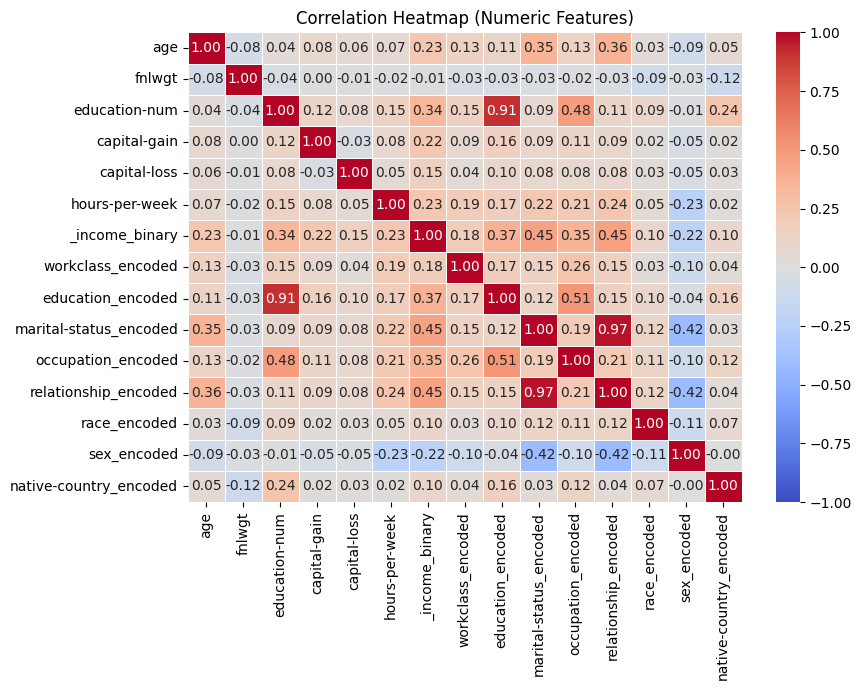

In [7]:
num_cols = df_encoded.select_dtypes(include=np.number).columns

corr_2 = df_encoded[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_2, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


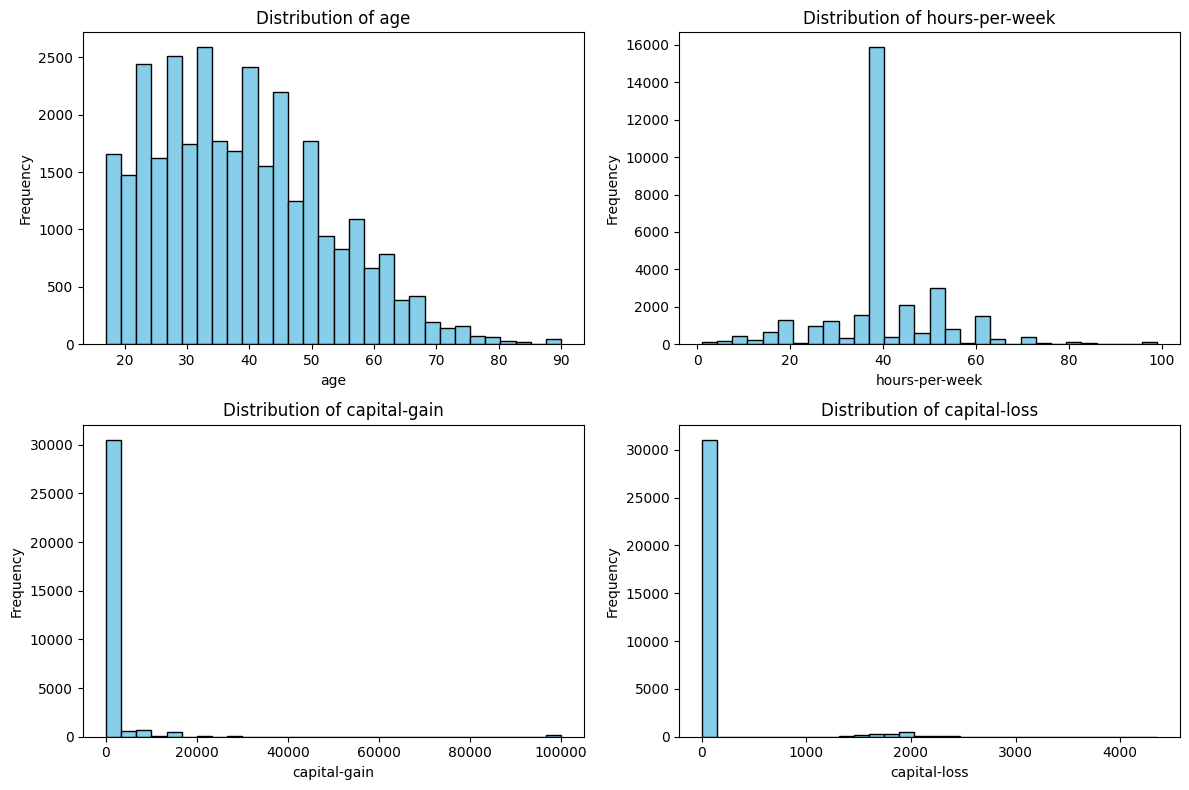

In [17]:
# Create histograms for all numeric variables
fig, axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Modelling

In [8]:
# Split X/y
X = df.drop(columns=["income","fnlwgt","education-num"])
y = df["income"]

# Identify categorical vs numeric columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = ['age','hours-per-week','capital-gain','capital-loss']

# Preprocessing (same for all models)
preprocess = ColumnTransformer(
    transformers=[
        ("cat", ce.TargetEncoder(cols=cat_cols), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

# Train/test split (same for all models)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Models to test
models = {
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "KNN": KNeighborsClassifier()
}

best_model = None
best_accuracy = 0
# Loop over models
for name, clf in models.items():
    print("\n" + "="*60)
    print(f"MODEL: {name}")
    print("="*60)

    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("clf", clf)
    ])

    # Train
    model.fit(X_train, y_train)

    # Predict
    preds = model.predict(X_test)

    accuracy = accuracy_score(y_test, preds)
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_model_name = name

    # Metrics
    print("Accuracy:", accuracy_score(y_test, preds))
    print("\nClassification Report:\n", classification_report(y_test, preds))
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))

print(f"\nBest Model: {best_model_name} with Accuracy: {best_accuracy:.4f}")


MODEL: GradientBoosting
Accuracy: 0.8702594810379242

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.89      0.94      0.92      4945
        >50K       0.79      0.63      0.70      1568

    accuracy                           0.87      6513
   macro avg       0.84      0.79      0.81      6513
weighted avg       0.87      0.87      0.87      6513

Confusion Matrix:
 [[4673  272]
 [ 573  995]]

MODEL: RandomForest
Accuracy: 0.8522954091816367

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      4945
        >50K       0.71      0.65      0.68      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.78      0.79      6513
weighted avg       0.85      0.85      0.85      6513

Confusion Matrix:
 [[4538  407]
 [ 555 1013]]

MODEL: AdaBoost
Accuracy: 0.8581298940580377

Classification Report:
               precision    re

In [9]:
joblib.dump(best_model, '../models/income_classification_model_pipeline.pkl')

['../models/income_classification_model_pipeline.pkl']

In [10]:
# Save unique options for each categorical column
unique_options = {}
for col in cat_cols:
    unique_options[col] = df[col].dropna().unique().tolist()
joblib.dump(unique_options, '../models/income_classification_unique_options.pkl')

['../models/income_classification_unique_options.pkl']